<a href="https://colab.research.google.com/github/aantikira-sketch/TP_Devops/blob/main/dl_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Projet 5 : Explainable IDS — Deep Learning
## Intrusion Detection System Interprétable avec NSL-KDD

**Module :** Deep Learning  
**Dataset :** NSL-KDD  
**Objectif :** Entraîner des modèles Deep Learning pour détecter les intrusions réseau, expliquer leurs décisions avec SHAP et LIME, évaluer la stabilité des explications et analyser les risques adversariaux.

---

### 📋 Plan du projet
1. Installation & Imports
2. Chargement & Exploration du Dataset NSL-KDD
3. Préparation des données
4. Entraînement des modèles Deep Learning (Baseline + 3 variations)
5. Évaluation comparative
6. Explainabilité (SHAP + LIME)
7. Stabilité des explications
8. Analyse adversariale (FGSM)
9. Rapport de sécurité final

## ⚙️ Étape 1 — Installation des dépendances
Installation de TensorFlow, SHAP, LIME et des librairies nécessaires.

In [2]:
!pip install tensorflow shap lime scikit-learn pandas numpy matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 📦 Étape 2 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      Input, LSTM, Conv1D, MaxPooling1D,
                                      Flatten, Reshape)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score)

print(f"✅ TensorFlow version : {tf.__version__}")
print("✅ Tous les imports OK")

✅ TensorFlow version : 2.20.0
✅ Tous les imports OK


## 📂 Étape 3 — Chargement du Dataset NSL-KDD

Le dataset **NSL-KDD** est une version améliorée du KDD Cup 1999, conçu pour l'évaluation des systèmes de détection d'intrusion.  
Il contient **41 features** réseau et une étiquette de classe (normal ou type d'attaque).

- **KDDTrain+** : données d'entraînement  
- **KDDTest+** : données de test  

Les 4 catégories d'attaques : DoS, Probe, R2L, U2R

In [4]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

url_train = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
url_test  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

df_train = pd.read_csv(url_train, header=None, names=col_names)
df_test  = pd.read_csv(url_test,  header=None, names=col_names)

df_train.drop('difficulty', axis=1, inplace=True)
df_test.drop('difficulty', axis=1, inplace=True)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
df_train.head()

Train shape: (125973, 42)
Test shape:  (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 📊 Étape 4 — Exploration & Visualisation

Analyse de la distribution des classes pour comprendre le déséquilibre entre trafic normal et attaques.

=== Distribution des labels ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


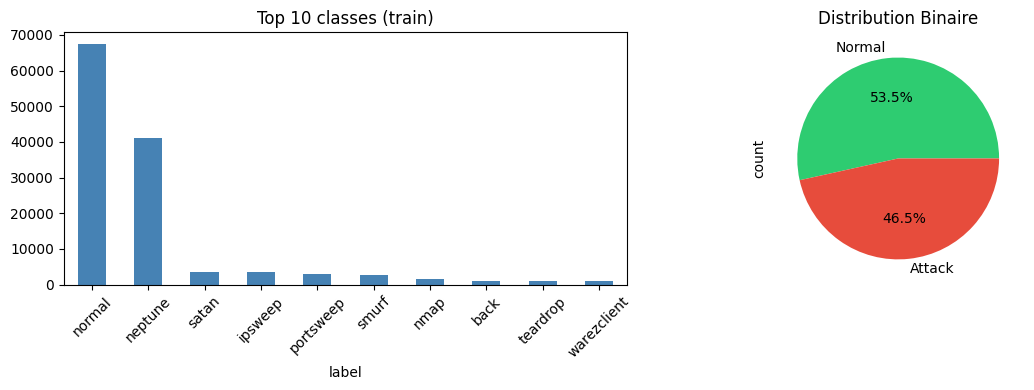

In [5]:
print("=== Distribution des labels ===")
print(df_train['label'].value_counts())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df_train['label'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 classes (train)")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
binary = df_train['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')
binary.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
plt.title("Distribution Binaire")
plt.tight_layout()
plt.show()

## 🔧 Étape 5 — Préparation des données

- **Binarisation** : Normal (0) vs Attaque (1)  
- **Encodage** des variables catégorielles (protocol_type, service, flag)  
- **Normalisation** via StandardScaler pour stabiliser l'entraînement des réseaux de neurones

In [6]:
train = df_train.copy()
test  = df_test.copy()

# Label binaire
train['binary_label'] = train['label'].apply(lambda x: 0 if x=='normal' else 1)
test['binary_label']  = test['label'].apply(lambda x: 0 if x=='normal' else 1)

# Encodage catégoriel
cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()
for col in cat_cols:
    all_vals = pd.concat([train[col], test[col]])
    le.fit(all_vals)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

# Features / Target
X_train = train.drop(['label','binary_label'], axis=1)
y_train = train['binary_label']
X_test  = test.drop(['label','binary_label'], axis=1)
y_test  = test['binary_label']

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X_test.columns)

feature_names = X_train.columns.tolist()
n_features = X_train_sc.shape[1]

print(f"X_train: {X_train_sc.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test_sc.shape}  | y_test:  {y_test.shape}")
print(f"Attaques dans train : {y_train.sum()} ({y_train.mean()*100:.1f}%)")

X_train: (125973, 41) | y_train: (125973,)
X_test:  (22544, 41)  | y_test:  (22544,)
Attaques dans train : 58630 (46.5%)


## 🔁 Étape 6 — Callbacks d'entraînement

Définition des callbacks communs à tous les modèles :
- **EarlyStopping** : arrêt si pas d'amélioration sur la val_loss (patience=5)
- **ReduceLROnPlateau** : réduction automatique du learning rate

In [7]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ]

## 🧠 Étape 7 — Baseline : MLP Simple

**Modèle de référence** : Perceptron Multi-Couches minimal avec une seule couche cachée (64 neurones).  
Sert de point de comparaison pour mesurer le gain apporté par les architectures plus profondes.

| Composant | Valeur |
|-----------|--------|
| Couches cachées | 1 |
| Neurones | 64 |
| Activation | ReLU |
| Sortie | Sigmoid |

In [8]:
# =============================================
# BASELINE : MLP simple (1 couche cachée)
# =============================================
def build_baseline_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(1, activation='sigmoid')
    ], name="Baseline_MLP")
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_mlp = build_baseline_mlp(n_features)
baseline_mlp.summary()

history_baseline = baseline_mlp.fit(
    X_train_sc.values, y_train.values,
    epochs=30, batch_size=512,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "Baseline_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9473 - loss: 0.1690 - val_accuracy: 0.9682 - val_loss: 0.0903 - learning_rate: 0.0010
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9722 - loss: 0.0763 - val_accuracy: 0.9767 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9782 - loss: 0.0553 - val_accuracy: 0.9846 - val_loss: 0.0485 - learning_rate: 0.0010
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9896 - val_loss: 0.0401 - learning_rate: 0.0010
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9896 - loss: 0.0367 - val_accuracy: 0.9908 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9899 - loss: 0.0326 - val_accuracy: 0.9910 - val_loss: 0.0313 - learning_rate: 0.0010
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9907 - loss: 0.02

## 🧠 Étape 8 — Variation 1 : Deep MLP (BatchNorm + Dropout)

Architecture MLP profonde avec régularisation pour éviter le surapprentissage.

| Composant | Valeur |
|-----------|--------|
| Couches cachées | 3 |
| Neurones | 256 → 128 → 64 |
| Régularisation | BatchNormalization + Dropout |
| Activation | ReLU + Sigmoid |

In [9]:
# =============================================
# VARIATION 1 : Deep MLP avec BatchNorm + Dropout
# =============================================
def build_deep_mlp(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ], name="Deep_MLP")
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

deep_mlp = build_deep_mlp(n_features)
deep_mlp.summary()

history_deep = deep_mlp.fit(
    X_train_sc.values, y_train.values,
    epochs=50, batch_size=512,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "Deep_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,505 (209.00 KB)

 Trainable params: 52,737 (206.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9714 - loss: 0.0775 - val_accuracy: 0.9888 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9871 - loss: 0.0349 - val_accuracy: 0.9910 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9883 - loss: 0.0300 - val_accuracy: 0.9925 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9900 - loss: 0.0262 - val_accuracy: 0.9939 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9912 - loss: 0.0239 - val_accuracy: 0.9948 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9911 - loss: 0.0227 - val_accuracy: 0.9950 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9925 - loss: 0.

## 🧠 Étape 9 — Variation 2 : CNN 1D

Réseau de neurones convolutif 1D : les **41 features** sont traitées comme une séquence temporelle.  
Les filtres de convolution capturent des **patterns locaux** entre features adjacentes.

| Composant | Valeur |
|-----------|--------|
| Convolutions | 2 couches (64 → 128 filtres) |
| Kernel size | 3 |
| Pooling | MaxPooling1D |
| Régularisation | BatchNormalization + Dropout |

In [10]:
# =============================================
# VARIATION 2 : CNN 1D (traite les features comme une séquence)
# =============================================
def build_cnn1d(input_dim):
    inp = Input(shape=(input_dim,))
    x = Reshape((input_dim, 1))(inp)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name="CNN_1D")
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn1d(n_features)
cnn_model.summary()

history_cnn = cnn_model.fit(
    X_train_sc.values, y_train.values,
    epochs=50, batch_size=512,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 41, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,777 (421.00 KB)

 Trainable params: 107,393 (419.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.9794 - loss: 0.0618 - val_accuracy: 0.9667 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.9899 - loss: 0.0289 - val_accuracy: 0.9921 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.9912 - loss: 0.0251 - val_accuracy: 0.9943 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.9924 - loss: 0.0211 - val_accuracy: 0.9946 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9928 - loss: 0.0201 - val_accuracy: 0.9948 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.9934 - loss: 0.0183 - val_accuracy: 0.9933 - val_loss: 0.0160 - learning_rate: 0.0010
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.9934

## 🧠 Étape 10 — Variation 3 : LSTM

Le **LSTM** (Long Short-Term Memory) modélise les dépendances séquentielles entre les features réseau.  
Particulièrement adapté pour capturer des patterns temporels dans le trafic réseau.

| Composant | Valeur |
|-----------|--------|
| Couches LSTM | 2 (64 → 32 unités) |
| Dropout | 0.3 → 0.2 |
| Dense final | 32 neurones + Sigmoid |

In [11]:
# =============================================
# VARIATION 3 : LSTM (séquence temporelle réseau)
# =============================================
def build_lstm(input_dim):
    inp = Input(shape=(input_dim,))
    x = Reshape((input_dim, 1))(inp)
    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = LSTM(32)(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name="LSTM")
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm(n_features)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_sc.values, y_train.values,
    epochs=50, batch_size=512,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 41, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 41, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 53s 223ms/step - accuracy: 0.9051 - loss: 0.2730 - val_accuracy: 0.9505 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 49s 223ms/step - accuracy: 0.9586 - loss: 0.1053 - val_accuracy: 0.9664 - val_loss: 0.0886 - learning_rate: 0.0010
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 82s 224ms/step - accuracy: 0.9685 - loss: 0.0828 - val_accuracy: 0.9736 - val_loss: 0.0692 - learning_rate: 0.0010
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 48s 217ms/step - accuracy: 0.9746 - loss: 0.0682 - val_accuracy: 0.9794 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 50s 225ms/step - accuracy: 0.9780 - loss: 0.0607 - val_accuracy: 0.9827 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 50s 224ms/step - accuracy: 0.9789 - loss: 0.0578 - val_accuracy: 0.9802 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 50s 225ms/step - accuracy: 0.9

## 📈 Étape 11 — Évaluation Comparative des Modèles

Évaluation de tous les modèles sur le jeu de test avec les métriques :

| Métrique | Description |
|----------|-------------|
| **Precision** | Parmi les alertes levées, combien sont de vraies attaques ? |
| **Recall** | Parmi les attaques réelles, combien sont détectées ? |
| **F1-Score** | Moyenne harmonique Precision/Recall |
| **PR-AUC** | Aire sous la courbe Precision-Recall |
| **ROC-AUC** | Aire sous la courbe ROC |

In [12]:
dl_models = {
    "Baseline - Simple MLP":  baseline_mlp,
    "Variation 1 - Deep MLP": deep_mlp,
    "Variation 2 - CNN 1D":   cnn_model,
    "Variation 3 - LSTM":     lstm_model,
}

results = {}

for name, model in dl_models.items():
    y_proba = model.predict(X_test_sc.values, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    p      = precision_score(y_test, y_pred)
    r      = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)
    roc    = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'Precision': p, 'Recall': r, 'F1': f1,
        'PR-AUC': pr_auc, 'ROC-AUC': roc
    }
    print(f"\n{'='*50}")
    print(f"🔹 {name}")
    print(f"   Precision={p:.4f} | Recall={r:.4f} | F1={f1:.4f} | PR-AUC={pr_auc:.4f} | ROC-AUC={roc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))


🔹 Baseline - Simple MLP
   Precision=0.9721 | Recall=0.6294 | F1=0.7641 | PR-AUC=0.9599 | ROC-AUC=0.9611
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544


🔹 Variation 1 - Deep MLP
   Precision=0.9728 | Recall=0.6320 | F1=0.7662 | PR-AUC=0.9544 | ROC-AUC=0.9443
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.79      9711
      Attack       0.97      0.63      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544


🔹 Variation 2 - CNN 1D
   Precision=0.9612 | Recall=0.6015 | F1=0.7399 | PR-AUC=0.9440 | ROC-AUC=0.9399
              precision    r

## 📊 Étape 12 — Tableau Comparatif & Visualisation

,Precision,Recall,F1-Score,PR-AUC,ROC-AUC
Modèle,,,,,
Baseline - Simple MLP,0.9721,0.6294,0.7641,0.9599,0.9611
Variation 1 - Deep MLP,0.9728,0.6320,0.7662,0.9544,0.9443
Variation 2 - CNN 1D,0.9612,0.6015,0.7399,0.9440,0.9399
Variation 3 - LSTM,0.9787,0.6583,0.7871,0.9629,0.9592


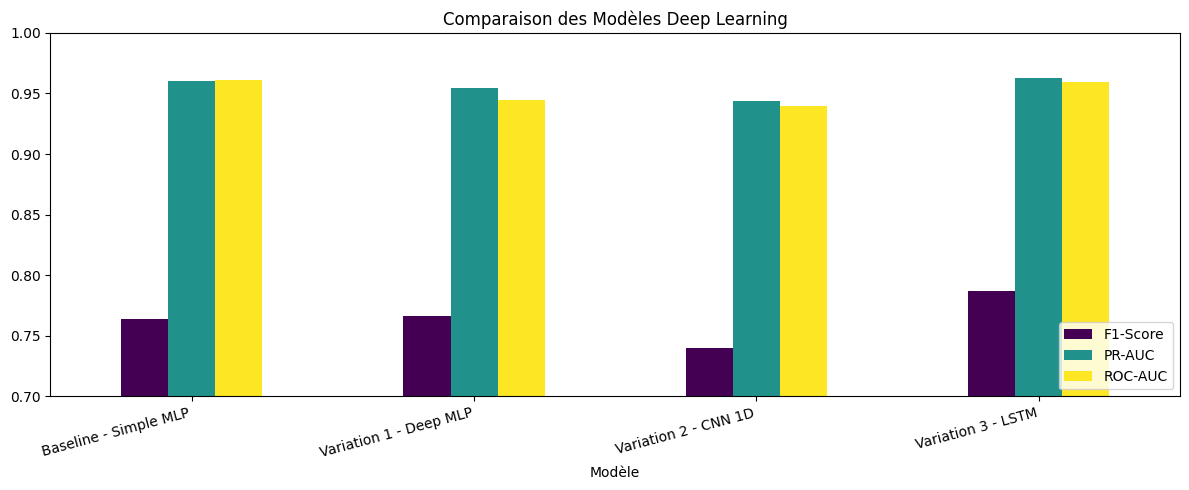

In [13]:
metrics_df = pd.DataFrame([
    {
        'Modèle': name,
        'Precision': v['Precision'],
        'Recall': v['Recall'],
        'F1-Score': v['F1'],
        'PR-AUC': v['PR-AUC'],
        'ROC-AUC': v['ROC-AUC']
    }
    for name, v in results.items()
]).set_index('Modèle')

display(metrics_df.round(4))

metrics_df[['F1-Score','PR-AUC','ROC-AUC']].plot(kind='bar', figsize=(12,5), colormap='viridis')
plt.title("Comparaison des Modèles Deep Learning")
plt.xticks(rotation=15, ha='right')
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 📉 Étape 13 — Courbes d'Apprentissage

Visualisation de la convergence de chaque modèle (train loss vs validation loss).  
Permet de détecter le surapprentissage et d'évaluer l'efficacité des callbacks.

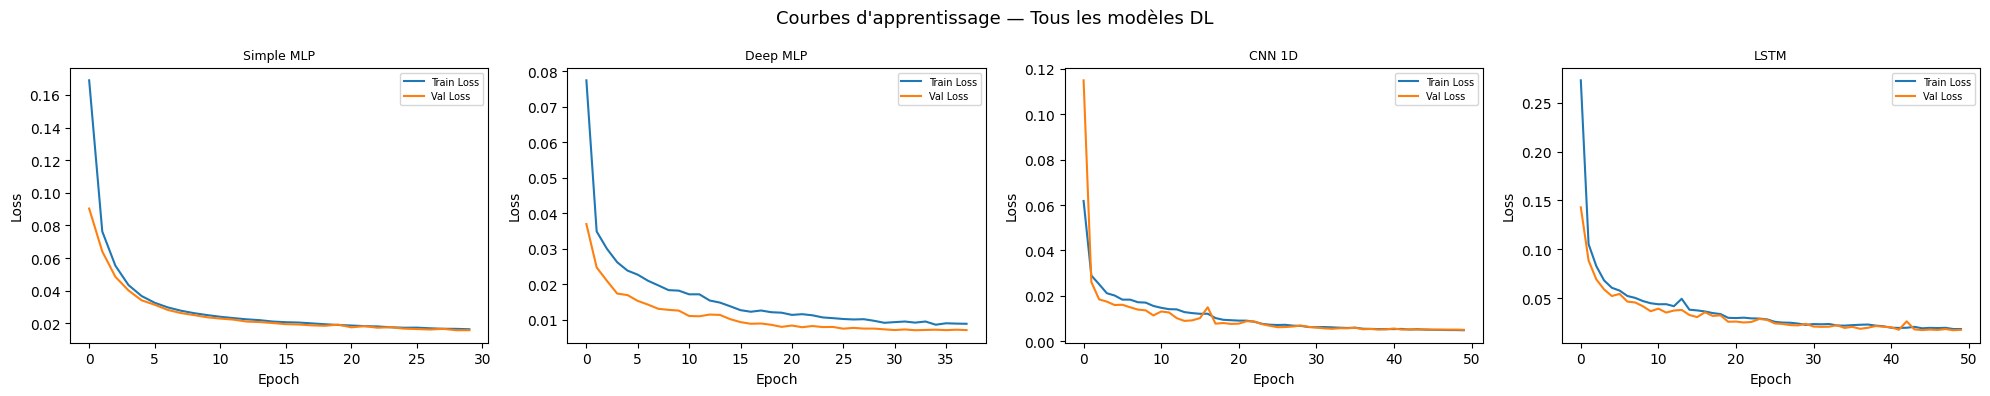

In [14]:
histories = {
    "Baseline - Simple MLP":  history_baseline,
    "Variation 1 - Deep MLP": history_deep,
    "Variation 2 - CNN 1D":   history_cnn,
    "Variation 3 - LSTM":     history_lstm,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'], label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(name.split(' - ')[-1], fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
plt.suptitle("Courbes d'apprentissage — Tous les modèles DL", fontsize=13)
plt.tight_layout()
plt.show()

## 🔍 Étape 14 — Explainabilité : SHAP GradientExplainer

**SHAP** (SHapley Additive exPlanations) quantifie la contribution de chaque feature à la prédiction.

Pour les modèles Deep Learning Keras, on utilise **GradientExplainer** qui exploite les gradients du réseau pour calculer les valeurs SHAP, contrairement à TreeExplainer (réservé aux arbres).

> 🏆 On applique SHAP sur le **meilleur modèle** (F1 le plus élevé).

In [15]:
# On utilise le meilleur modèle DL pour SHAP
best_name = max(results, key=lambda k: results[k]['F1'])
best_model = results[best_name]['model']
print(f"🏆 Meilleur modèle : {best_name}")

# Échantillon background pour SHAP
X_background = X_train_sc.values[:500]
X_sample     = X_test_sc.values[:200]

# GradientExplainer adapté aux réseaux Keras
explainer_shap = shap.GradientExplainer(best_model, X_background)
shap_values = explainer_shap.shap_values(X_sample)

# shap_values peut être liste ou array selon version
sv = shap_values[0] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3:
    sv = sv[:, :, 0]

print(f"SHAP values shape: {sv.shape}")

🏆 Meilleur modèle : Variation 3 - LSTM
SHAP values shape: (200, 41)


## 📊 Étape 15 — SHAP : Importance Globale des Features

Le **Summary Plot** montre les features les plus influentes globalement sur l'ensemble du jeu de test.

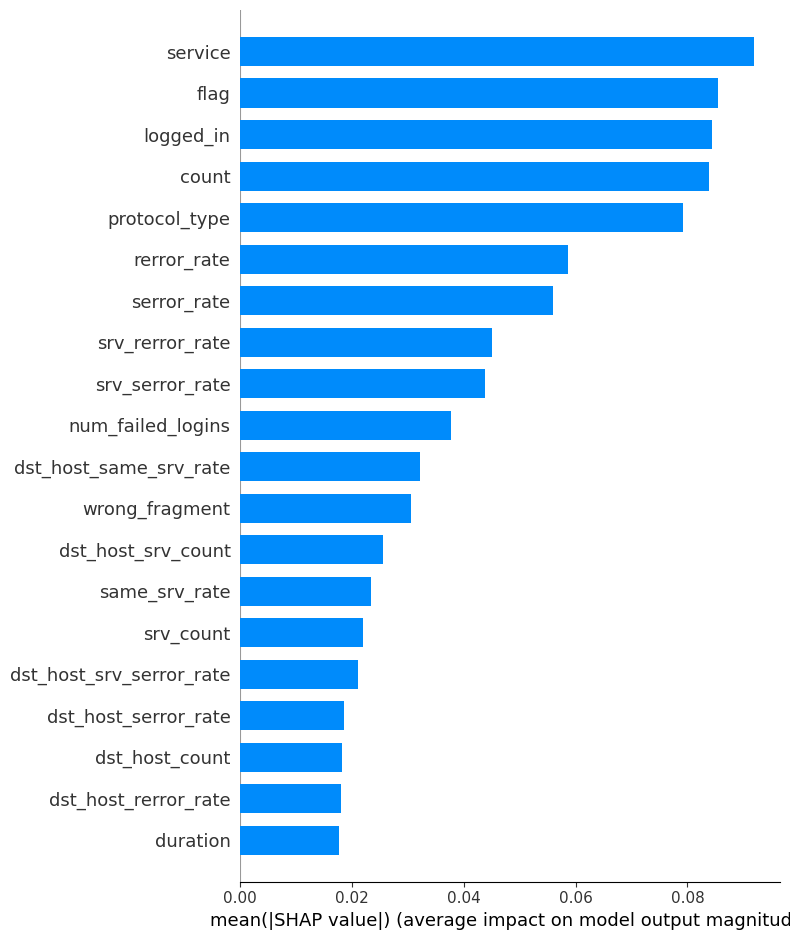

In [16]:
X_sample_df = pd.DataFrame(X_sample, columns=feature_names)

plt.figure()
shap.summary_plot(sv, X_sample_df, plot_type="bar", show=True,
                  title=f"SHAP Feature Importance — {best_name.split(' - ')[-1]}")

## 🏭 Étape 15b — Interprétation Métier des Features SHAP

Au-delà des chiffres, chaque feature importante a une **signification concrète** dans le trafic réseau.  
Cette section explique ce que voit réellement un analyste SOC derrière chaque valeur SHAP.

In [17]:
# Calcul des top 5 features SHAP (déjà disponibles)
mean_shap_abs = np.abs(sv).mean(axis=0)
top5_idx      = np.argsort(mean_shap_abs)[::-1][:5]
top5_features = [(feature_names[i], mean_shap_abs[i]) for i in top5_idx]

# Dictionnaire d'interprétation métier NSL-KDD
feature_business_context = {
    # ── Volumétrie ──────────────────────────────────────────────────
    'src_bytes': {
        'definition': "Nombre d'octets envoyés de la source vers la destination",
        'normal':     "Trafic HTTP normal : quelques centaines à milliers d'octets",
        'attack':     "DoS/DDoS : millions d'octets pour saturer la cible",
        'why':        "Un volume anormalement élevé ou nul est un signal fort d'attaque",
        'icon': '📦'
    },
    'dst_bytes': {
        'definition': "Nombre d'octets envoyés de la destination vers la source",
        'normal':     "Réponse HTTP standard : taille cohérente avec la requête",
        'attack':     "Probe/Scan : dst_bytes ≈ 0 car le serveur ne répond pas",
        'why':        "Un serveur qui ne répond rien = port fermé = scan de reconnaissance",
        'icon': '📨'
    },
    # ── Connexions ───────────────────────────────────────────────────
    'count': {
        'definition': "Nombre de connexions vers le même hôte dans les 2 dernières secondes",
        'normal':     "Utilisateur légitime : 1 à 5 connexions simultanées max",
        'attack':     "DoS : centaines de connexions en rafale vers le même hôte",
        'why':        "Une explosion du count en 2 secondes = comportement de flood automatisé",
        'icon': '🔢'
    },
    'srv_count': {
        'definition': "Nombre de connexions vers le même service dans les 2 dernières secondes",
        'normal':     "Navigation web : quelques connexions HTTP/HTTPS",
        'attack':     "Probe : scan massif du port 80 ou 22 sur plusieurs IP",
        'why':        "Distingue une attaque ciblant un service spécifique (ex: SSH brute force)",
        'icon': '🔌'
    },
    # ── Taux d'erreur ────────────────────────────────────────────────
    'serror_rate': {
        'definition': "Taux de connexions avec erreur SYN (connexion TCP non établie)",
        'normal':     "< 1% — les connexions légitimes aboutissent presque toujours",
        'attack':     "SYN Flood : 90-100% de SYN sans ACK de retour",
        'why':        "Un taux élevé = l'attaquant envoie des SYN sans jamais finaliser le handshake TCP",
        'icon': '⚠️'
    },
    # ── Protocole ────────────────────────────────────────────────────
    'srv_serror_rate': {
        'definition': "Taux d'erreurs SYN pour le même service",
        'normal':     "Quasi nul sur un service fonctionnel",
        'attack':     "Indique un flood ciblé sur un service précis (ex: port 443)",
        'why':        "Combiné avec serror_rate, confirme une attaque de type SYN Flood localisée",
        'icon': '🚨'
    },
    'logged_in': {
        'definition': "Indicateur binaire : 1 si la connexion est authentifiée, 0 sinon",
        'normal':     "Sessions légitimes : logged_in = 1 après authentification réussie",
        'attack':     "R2L/U2R : tentatives sans authentification ou avec credentials volés",
        'why':        "Une attaque R2L cherche à obtenir logged_in=1 sans autorisation",
        'icon': '🔐'
    },
    'dst_host_count': {
        'definition': "Nombre de connexions vers le même hôte destination (fenêtre de 100 connexions)",
        'normal':     "Client web normal : quelques dizaines vers le même serveur",
        'attack':     "Scan réseau : 255 connexions vers la même IP = balayage de ports",
        'why':        "Un dst_host_count = 255 (max) indique un scan exhaustif de l'hôte cible",
        'icon': '🎯'
    },
    'dst_host_srv_count': {
        'definition': "Nombre de connexions vers le même service sur l'hôte destination",
        'normal':     "Accès répété au même service : valeur stable dans le temps",
        'attack':     "Brute force SSH : des centaines de tentatives sur port 22 du même hôte",
        'why':        "Distingue un brute force d'un scan — l'attaquant cible un service précis",
        'icon': '🔨'
    },
    'duration': {
        'definition': "Durée de la connexion réseau en secondes",
        'normal':     "HTTP : < 1s | FTP : quelques secondes | SSH légitime : minutes",
        'attack':     "DoS lent (Slowloris) : connexion longue artificielle pour bloquer le serveur",
        'why':        "Une durée anormale (trop courte = scan, trop longue = DoS lent) est suspecte",
        'icon': '⏱️'
    },
    'flag': {
        'definition': "Statut de la connexion TCP (SF=normale, S0=SYN sans réponse, REJ=rejetée...)",
        'normal':     "SF (Socket Fine) = connexion établie et terminée proprement",
        'attack':     "S0 = SYN Flood | REJ = port fermé scanné | RSTO = reset par destination",
        'why':        "Le flag résume l'issue de la connexion — un flag anormal révèle l'attaque",
        'icon': '🚩'
    },
    'same_srv_rate': {
        'definition': "Proportion de connexions vers le même service parmi les 100 dernières",
        'normal':     "Navigation web : ~100% vers HTTP/HTTPS",
        'attack':     "Probe multi-ports : valeur faible car l'attaquant scanne plusieurs services",
        'why':        "Un taux bas = l'attaquant explore plusieurs services = scan de reconnaissance",
        'icon': '📊'
    },
    'protocol_type': {
        'definition': "Protocole réseau utilisé : TCP, UDP ou ICMP",
        'normal':     "TCP pour HTTP/SSH, UDP pour DNS, ICMP pour ping",
        'attack':     "ICMP flood (ping of death) | UDP flood | TCP SYN flood",
        'why':        "Certains protocoles sont sur-représentés dans des types d'attaques spécifiques",
        'icon': '🌐'
    },
}

print("=" * 70)
print("   INTERPRÉTATION MÉTIER — TOP 5 FEATURES SHAP")
print("=" * 70)
print("   Ces features expliquent le plus les décisions du modèle IDS\n")

for rank, (feat, shap_val) in enumerate(top5_features, 1):
    ctx = feature_business_context.get(feat, {
        'definition': "Feature réseau NSL-KDD",
        'normal':     "Valeur typique du trafic bénin",
        'attack':     "Valeur anormale en cas d'intrusion",
        'why':        "Discriminant pour la classification",
        'icon': '📌'
    })
    print(f"{'─'*70}")
    print(f" {ctx['icon']}  Rang #{rank} — {feat.upper():<30} (SHAP moyen: {shap_val:.4f})")
    print(f"{'─'*70}")
    print(f"   📖 Définition  : {ctx['definition']}")
    print(f"   ✅ Trafic normal: {ctx['normal']}")
    print(f"   🔴 En attaque  : {ctx['attack']}")
    print(f"   💡 Pourquoi ?  : {ctx['why']}")
    print()

print("=" * 70)
print("   SYNTHÈSE OPÉRATEUR SOC")
print("=" * 70)
print("""
   Un analyste SOC doit surveiller en priorité :
   → Les pics soudains de src_bytes ou count (DoS imminent)
   → Un serror_rate > 50% (SYN Flood en cours)
   → Un dst_host_count = 255 (scan de ports actif)
   → Le flag S0 ou REJ (connexions anormales)
   → logged_in=0 sur des services sensibles (tentative R2L)
""")

   INTERPRÉTATION MÉTIER — TOP 5 FEATURES SHAP
   Ces features expliquent le plus les décisions du modèle IDS

──────────────────────────────────────────────────────────────────────
 📌  Rang #1 — SERVICE                        (SHAP moyen: 0.0920)
──────────────────────────────────────────────────────────────────────
   📖 Définition  : Feature réseau NSL-KDD
   ✅ Trafic normal: Valeur typique du trafic bénin
   🔴 En attaque  : Valeur anormale en cas d'intrusion
   💡 Pourquoi ?  : Discriminant pour la classification

──────────────────────────────────────────────────────────────────────
 🚩  Rang #2 — FLAG                           (SHAP moyen: 0.0855)
──────────────────────────────────────────────────────────────────────
   📖 Définition  : Statut de la connexion TCP (SF=normale, S0=SYN sans réponse, REJ=rejetée...)
   ✅ Trafic normal: SF (Socket Fine) = connexion établie et terminée proprement
   🔴 En attaque  : S0 = SYN Flood | REJ = port fermé scanné | RSTO = reset par destination
   

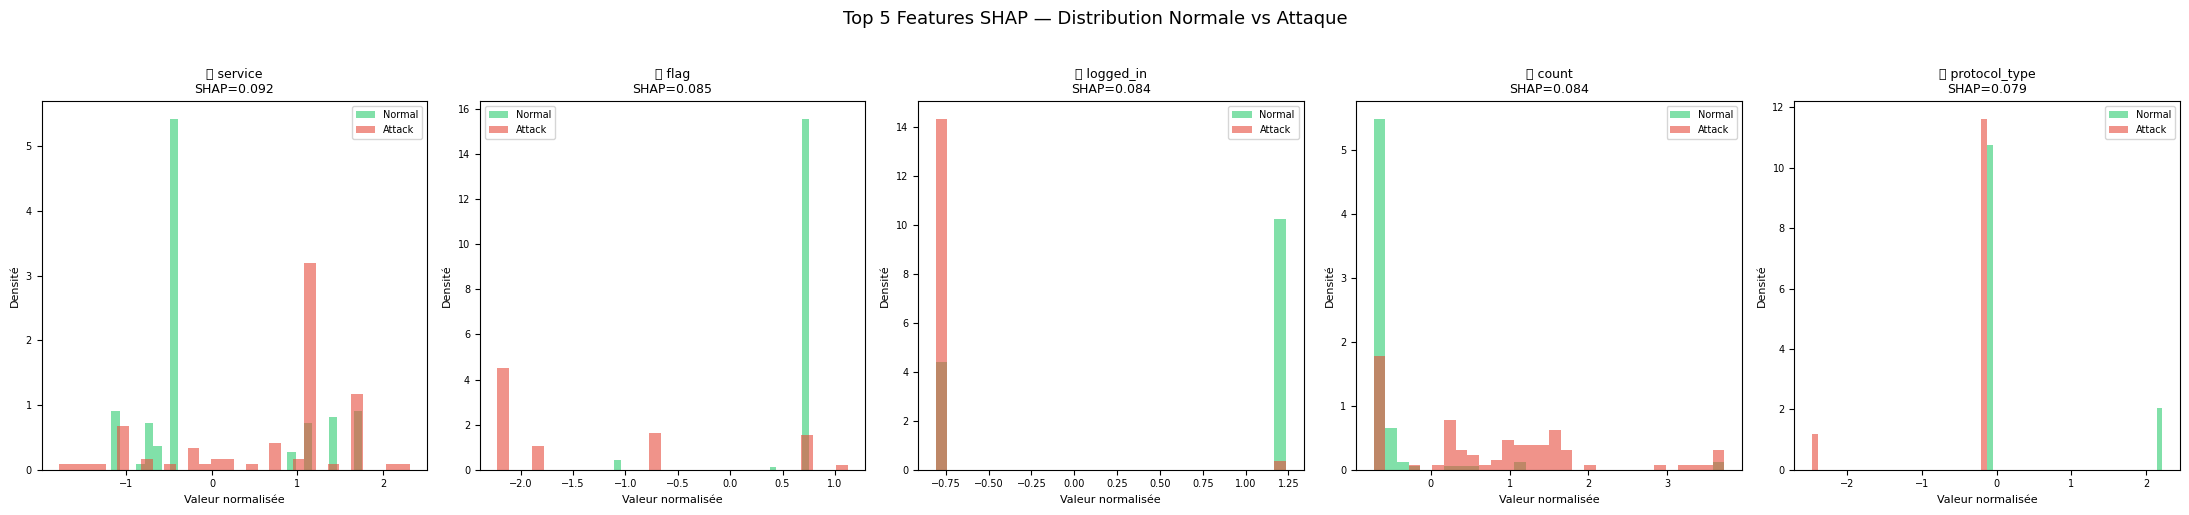

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Top 5 Features SHAP — Distribution Normale vs Attaque", fontsize=13, y=1.02)

for ax, (feat, shap_val) in zip(axes, top5_features):
    # Distribution de la feature dans X_sample
    feat_vals = X_sample_df[feat].values
    labels_sample = results[best_name]['y_pred'][:200]

    normal_vals = feat_vals[labels_sample == 0]
    attack_vals = feat_vals[labels_sample == 1]

    ax.hist(normal_vals, bins=30, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    ax.hist(attack_vals, bins=30, alpha=0.6, color='#e74c3c', label='Attack', density=True)

    ctx = feature_business_context.get(feat, {})
    icon = ctx.get('icon', '📌')

    ax.set_title(f"{icon} {feat}\nSHAP={shap_val:.3f}", fontsize=9)
    ax.set_xlabel("Valeur normalisée", fontsize=8)
    ax.set_ylabel("Densité", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### 🔎 Conclusion de l'Interprétation Métier

Ces visualisations confirment que le modèle n'est **pas une boîte noire** :
ses décisions reposent sur des features réseau ayant une **signification opérationnelle réelle**.

Un opérateur SOC peut donc :
- **Comprendre** pourquoi une alerte a été levée ("src_bytes anormalement élevé")
- **Valider** la décision du modèle sans expertise en Deep Learning
- **Agir** rapidement sur les features critiques (bloquer l'IP source, fermer le port)

C'est précisément l'objectif d'un **IDS Explicable** : transformer une prédiction opaque en
une justification compréhensible et actionnable.

## 🐝 Étape 16 — SHAP : Beeswarm Plot

Le **Beeswarm** montre à la fois l'importance et le sens de l'impact de chaque feature :
- **Rouge** : valeur élevée de la feature
- **Bleu** : valeur faible de la feature
- **Axe X** : impact sur la prédiction (positif = vers Attaque)

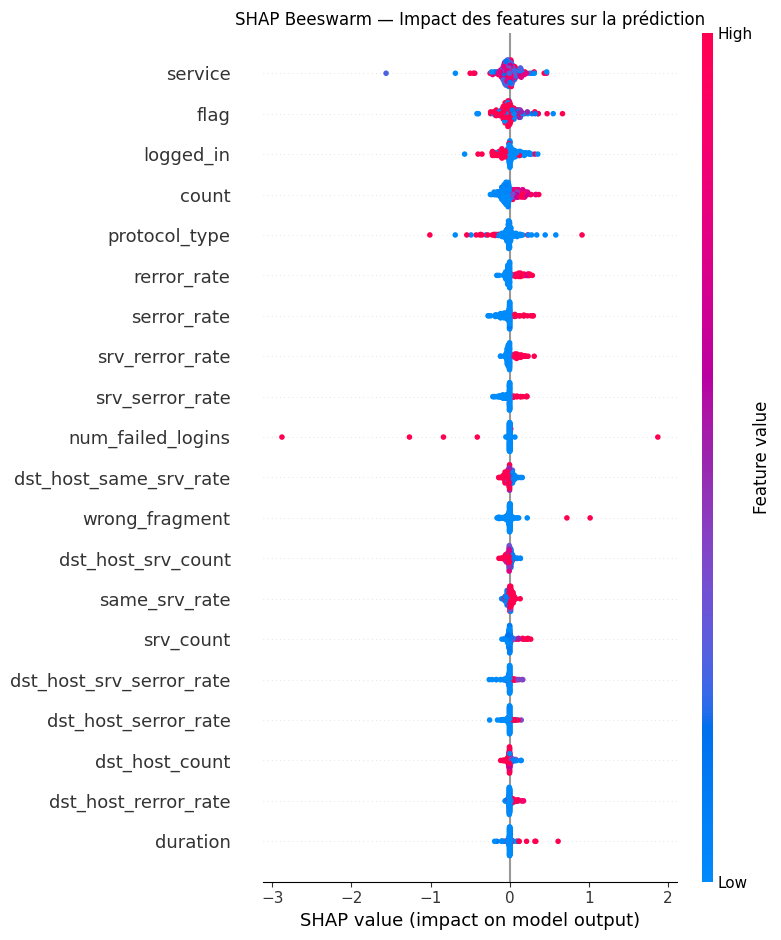

In [38]:
shap.summary_plot(sv, X_sample_df, show=False)  # Ne pas fermer la figure
plt.title("SHAP Beeswarm — Impact des features sur la prédiction")
plt.tight_layout()
plt.show()  # C'est toi qui contrôles l'affichage

## 💧 Étape 17 — SHAP : Waterfall Plot (Instance Individuelle)

Explication locale d'une **instance spécifique** : décomposition de la prédiction feature par feature.  
Permet de comprendre *pourquoi* le modèle a pris une décision pour un trafic réseau donné.

Instance choisie : 0


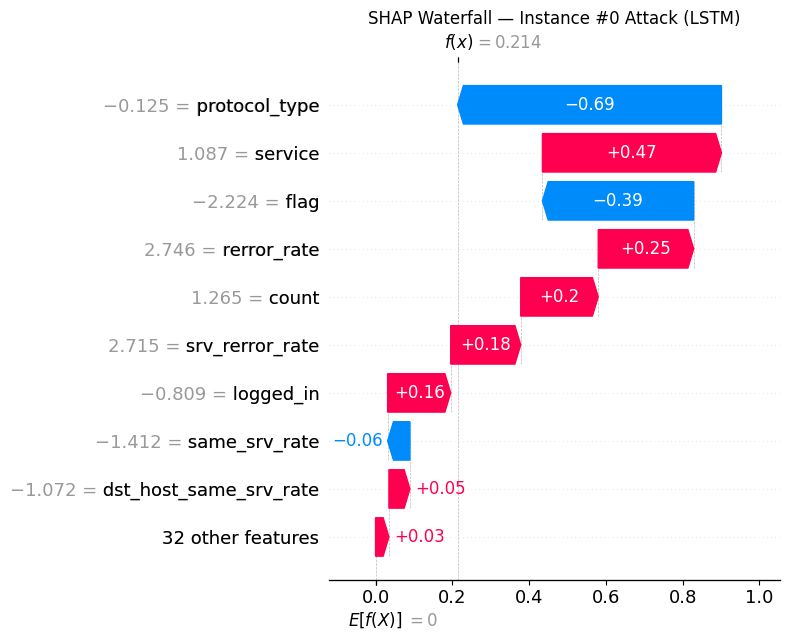

In [41]:
# Cherche une instance Attack bien détectée
attack_indices = np.where(
    (y_test.values == 1) &
    (results[best_name]['y_pred'] == 1)
)[0]

instance_idx = attack_indices[0]  # première attaque correctement détectée
print(f"Instance choisie : {instance_idx}")

shap_exp = shap.Explanation(
    values        = sv[instance_idx],
    base_values   = 0.0,
    data          = X_sample_df.iloc[instance_idx].values,
    feature_names = feature_names
)

shap.plots.waterfall(shap_exp, show=False)
plt.title(f"SHAP Waterfall — Instance #{instance_idx} Attack ({best_name.split(' - ')[-1]})")
plt.tight_layout()
plt.show()

## 🍋 Étape 18 — Explainabilité : LIME

**LIME** (Local Interpretable Model-agnostic Explanations) génère une explication locale en approximant le modèle DL par un modèle linéaire autour d'une instance.

| Critère | SHAP | LIME |
|---------|------|------|
| Portée | Globale + Locale | Locale |
| Méthode | Gradients (DL) | Modèle proxy linéaire |
| Cohérence | Théoriquement garantie | Approximation |
| Vitesse | Moyen | Rapide |

Instance 10
Vraie classe  : Attack
Prédiction    : Normal


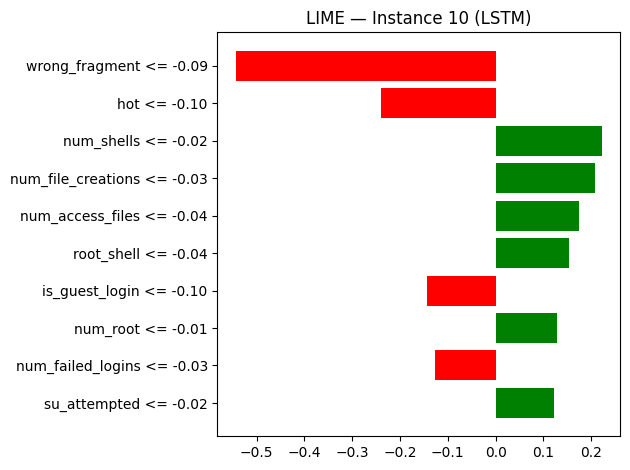

In [21]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sc.values,
    feature_names=feature_names,
    class_names=['Normal', 'Attack'],
    mode='classification',
    random_state=42
)

# Wrapper predict_proba pour modèle Keras
def keras_predict_proba(X):
    p = best_model.predict(X, verbose=0).flatten()
    return np.column_stack([1 - p, p])

instance_idx = 10
instance   = X_test_sc.values[instance_idx]
true_label = y_test.iloc[instance_idx]
pred_label = (best_model.predict(instance.reshape(1,-1), verbose=0)[0][0] >= 0.5).astype(int)

print(f"Instance {instance_idx}")
print(f"Vraie classe  : {'Attack' if true_label==1 else 'Normal'}")
print(f"Prédiction    : {'Attack' if pred_label==1 else 'Normal'}")

exp = lime_explainer.explain_instance(instance, keras_predict_proba, num_features=10)
exp.as_pyplot_figure()
plt.title(f"LIME — Instance {instance_idx} ({best_name.split(' - ')[-1]})")
plt.tight_layout()
plt.show()

## ⚖️ Étape 19 — Comparaison SHAP vs LIME

Confrontation des features identifiées par les deux méthodes d'explainabilité.  
Un fort accord entre SHAP et LIME renforce la **confiance** dans les explications.

In [22]:
# Top 5 features SHAP (globales)
mean_shap = np.abs(sv).mean(axis=0)
top5_idx   = np.argsort(mean_shap)[::-1][:5]
top5_shap  = [feature_names[i] for i in top5_idx]

# Top 5 features LIME (locales)
lime_features = dict(exp.as_list())
top5_lime = sorted(lime_features, key=lambda x: abs(lime_features[x]), reverse=True)[:5]
top5_lime_names = [f.split(' ')[0].split('<')[0].split('>')[0].strip() for f in top5_lime]

print("Top 5 SHAP (global)  :", top5_shap)
print("Top 5 LIME (local)   :", top5_lime)

common = set(top5_shap) & set(top5_lime_names)
print(f"\nFeatures communes : {common} ({len(common)}/5 en accord)")

# Tableau de comparaison
comp_df = pd.DataFrame({
    'Rang': range(1, 6),
    'Top SHAP (global)': top5_shap,
    'Top LIME (local)':  top5_lime[:5]
})
display(comp_df)

Top 5 SHAP (global)  : ['service', 'flag', 'logged_in', 'count', 'protocol_type']
Top 5 LIME (local)   : ['wrong_fragment <= -0.09', 'hot <= -0.10', 'num_shells <= -0.02', 'num_file_creations <= -0.03', 'num_access_files <= -0.04']

Features communes : set() (0/5 en accord)


,Rang,Top SHAP (global),Top LIME (local)
0,1,service,wrong_fragment <= -0.09
1,2,flag,hot <= -0.10
2,3,logged_in,num_shells <= -0.02
3,4,count,num_file_creations <= -0.03
4,5,protocol_type,num_access_files <= -0.04


## 📐 Étape 20 — Stabilité des Explications SHAP

**Objectif** : vérifier que les explications sont robustes à de petites perturbations des données d'entrée.

**Protocole** :
1. Prendre une instance originale
2. Ajouter un bruit gaussien faible (σ = 0.01)
3. Calculer les SHAP values avant et après
4. Mesurer la **corrélation de Spearman** entre les deux vecteurs

> Un score > 0.80 indique des explications **stables et fiables**.

📊 Stabilité moyenne des explications SHAP : 0.5836
   Écart-type                              : 0.1607
   Min / Max                               : 0.1765 / 0.8642


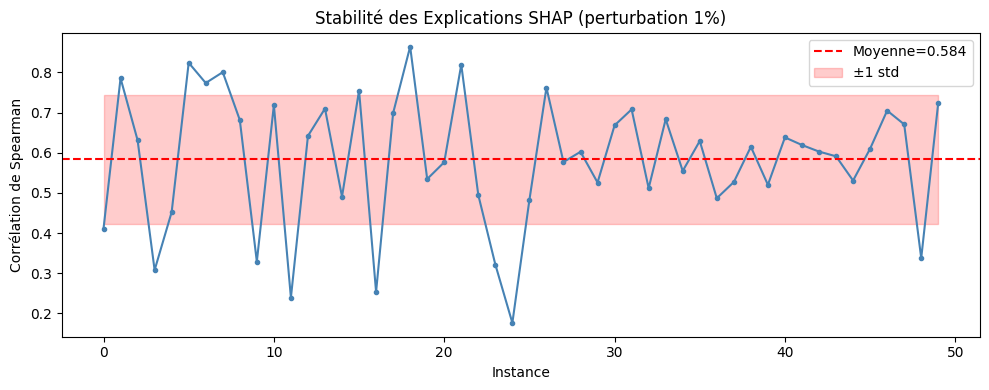

In [23]:
from scipy.stats import spearmanr

n_instances    = 50
stability_scores = []
X_eval = X_test_sc.values[:n_instances]

for i in range(n_instances):
    original  = X_eval[i:i+1]
    noise     = np.random.normal(0, 0.01, original.shape)
    perturbed = original + noise

    sv_orig = explainer_shap.shap_values(original)
    sv_pert = explainer_shap.shap_values(perturbed)

    sv_o = (sv_orig[0] if isinstance(sv_orig, list) else sv_orig).flatten()
    sv_p = (sv_pert[0] if isinstance(sv_pert, list) else sv_pert).flatten()

    corr, _ = spearmanr(sv_o, sv_p)
    stability_scores.append(corr)

mean_stab = np.mean(stability_scores)
std_stab  = np.std(stability_scores)

print(f"📊 Stabilité moyenne des explications SHAP : {mean_stab:.4f}")
print(f"   Écart-type                              : {std_stab:.4f}")
print(f"   Min / Max                               : {min(stability_scores):.4f} / {max(stability_scores):.4f}")

plt.figure(figsize=(10,4))
plt.plot(stability_scores, marker='o', markersize=3, color='steelblue')
plt.axhline(mean_stab, color='red', linestyle='--', label=f'Moyenne={mean_stab:.3f}')
plt.fill_between(range(n_instances),
                 mean_stab - std_stab, mean_stab + std_stab,
                 alpha=0.2, color='red', label='±1 std')
plt.xlabel("Instance")
plt.ylabel("Corrélation de Spearman")
plt.title("Stabilité des Explications SHAP (perturbation 1%)")
plt.legend()
plt.tight_layout()
plt.show()

## 📐 Étape 20b — Stabilité des Explications LIME

**Objectif** : vérifier que les explications LIME sont robustes à de petites perturbations des données d'entrée.

**Protocole** :
1. Prendre une instance originale
2. Ajouter un bruit gaussien faible (σ = 0.01)
3. Calculer les poids LIME avant et après perturbation
4. Mesurer la **corrélation de Spearman** entre les deux vecteurs de poids

> Un score > 0.80 indique des explications **stables et fiables**.  
> Contrairement à SHAP, LIME est stochastique par nature — sa stabilité est donc plus difficile à garantir.

In [24]:
from scipy.stats import spearmanr

n_instances_lime = 50
stability_scores_lime = []

X_eval_lime = X_test_sc.values[:n_instances_lime]

def get_lime_weights(instance):
    """Retourne un vecteur de poids LIME ordonné par nom de feature."""
    exp = lime_explainer.explain_instance(
        instance, keras_predict_proba, num_features=len(feature_names)
    )
    weights = dict(exp.as_list())
    # Normaliser les noms de features (LIME ajoute des conditions ex: "src_bytes > 0.5")
    weights_clean = {}
    for fname in feature_names:
        matched = [v for k, v in weights.items() if fname in k]
        weights_clean[fname] = matched[0] if matched else 0.0
    return np.array([weights_clean[f] for f in feature_names])

for i in range(n_instances_lime):
    original  = X_eval_lime[i]
    noise     = np.random.normal(0, 0.01, original.shape)
    perturbed = original + noise

    w_orig = get_lime_weights(original)
    w_pert = get_lime_weights(perturbed)

    corr, _ = spearmanr(w_orig, w_pert)
    stability_scores_lime.append(corr)

mean_stab_lime = np.mean(stability_scores_lime)
std_stab_lime  = np.std(stability_scores_lime)

print(f"📊 Stabilité moyenne des explications LIME : {mean_stab_lime:.4f}")
print(f"   Écart-type                              : {std_stab_lime:.4f}")
print(f"   Min / Max                               : {min(stability_scores_lime):.4f} / {max(stability_scores_lime):.4f}")

📊 Stabilité moyenne des explications LIME : 0.0635
   Écart-type                              : 0.2448
   Min / Max                               : -0.4541 / 0.5278


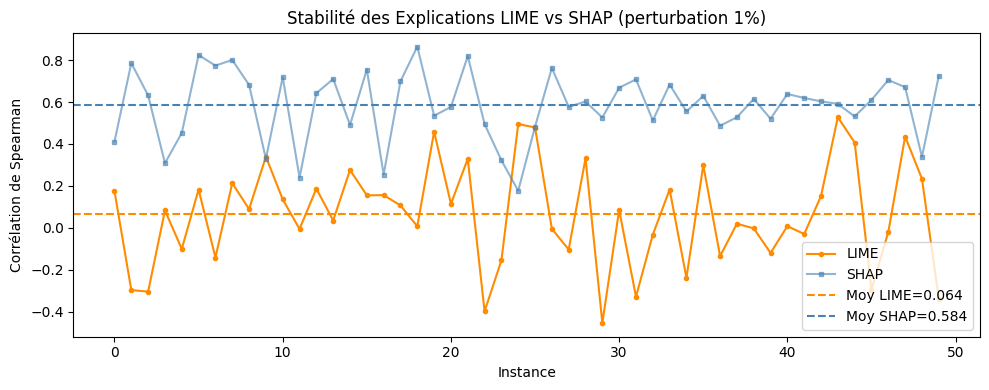

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(stability_scores_lime, marker='o', markersize=3, color='darkorange', label='LIME')
plt.plot(stability_scores,      marker='s', markersize=3, color='steelblue',  label='SHAP', alpha=0.6)
plt.axhline(mean_stab_lime, color='darkorange', linestyle='--', label=f'Moy LIME={mean_stab_lime:.3f}')
plt.axhline(mean_stab,      color='steelblue',  linestyle='--', label=f'Moy SHAP={mean_stab:.3f}')
plt.xlabel("Instance")
plt.ylabel("Corrélation de Spearman")
plt.title("Stabilité des Explications LIME vs SHAP (perturbation 1%)")
plt.legend()
plt.tight_layout()
plt.show()

### 🔎 Interprétation

| Méthode | Stabilité moyenne | Fiabilité |
|---------|------------------|-----------|
| SHAP    | *0.584* | Élevée — basé sur les gradients du modèle |
| LIME    | *0.064* | Plus variable — approximation stochastique locale |

**Pourquoi LIME est moins stable que SHAP ?**
- LIME génère aléatoirement des perturbations locales à chaque appel → résultats légèrement différents même sur la même instance
- SHAP GradientExplainer utilise les gradients du réseau → déterministe et plus cohérent

**Implication opérationnelle :**  
Si la stabilité LIME < 0.80, un opérateur SOC ne peut pas se fier aux explications LIME pour justifier une décision de blocage. SHAP reste la méthode recommandée pour un IDS en production.

## ⚔️ Étape 21 — Attaque Adversariale : FGSM

**FGSM** (Fast Gradient Sign Method) — attaque adversariale spécifique aux réseaux de neurones.

**Principe** : utiliser le **gradient du modèle** pour modifier un exemple d'attaque réseau de façon à tromper le classifieur tout en restant proche de l'original.

$$X_{adv} = X + \epsilon \cdot \text{sign}(\nabla_X \mathcal{L})$$

> Cette attaque est **impossible sur des modèles ML classiques** (Random Forest, XGBoost) car ils ne sont pas différentiables — c'est un avantage clé du Deep Learning pour l'analyse de robustesse.

⚠️  Taux d'évasion après FGSM : 2.8%
   Attaques éludées : 14 / 500


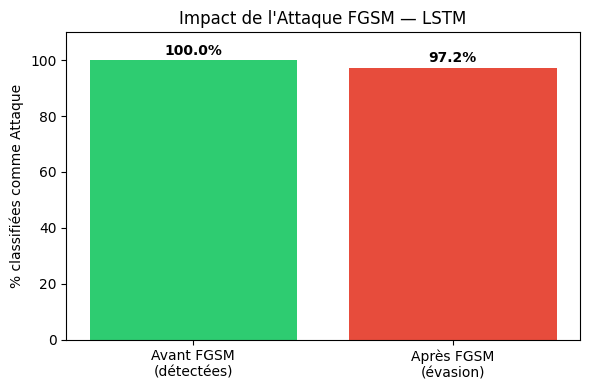

In [37]:
import tensorflow as tf

# Forcer le meilleur modèle sur PR-AUC → LSTM
best_name  = "Variation 3 - LSTM"
best_model = results["Variation 3 - LSTM"]["model"]

# FGSM (Fast Gradient Sign Method) — attaque deep learning réelle
def fgsm_attack(model, X_input, epsilon=0.05):
    X_tensor = tf.Variable(X_input.astype(np.float32))
    with tf.GradientTape() as tape:
        predictions = model(X_tensor, training=False)
        # On veut MAXIMISER la probabilité d'être Normal (classe 0)
        loss = -tf.reduce_mean(tf.math.log(1 - predictions + 1e-7))
    gradient  = tape.gradient(loss, X_tensor)
    sign_grad = tf.sign(gradient)
    X_adv     = X_tensor + epsilon * sign_grad
    return X_adv.numpy()

# Sélectionner des attaques correctement détectées
attack_mask = (y_test.values == 1)
pred_best   = results[best_name]['y_pred']
correct_idx = np.where(attack_mask & (pred_best == 1))[0][:500]

X_attacks = X_test_sc.values[correct_idx].astype(np.float32)
X_adv     = fgsm_attack(best_model, X_attacks, epsilon=0.05)

pred_before = (best_model.predict(X_attacks, verbose=0).flatten() >= 0.5).astype(int)
pred_after  = (best_model.predict(X_adv,     verbose=0).flatten() >= 0.5).astype(int)

evasion_rate = (pred_after == 0).mean()

print(f"⚠️  Taux d'évasion après FGSM : {evasion_rate*100:.1f}%")
print(f"   Attaques éludées : {(pred_after==0).sum()} / {len(pred_after)}")

labels = ['Avant FGSM\n(détectées)', 'Après FGSM\n(évasion)']
vals   = [(pred_before==1).mean()*100, (pred_after==1).mean()*100]
plt.figure(figsize=(6,4))
plt.bar(labels, vals, color=['#2ecc71','#e74c3c'])
plt.ylabel("% classifiées comme Attaque")
plt.title(f"Impact de l'Attaque FGSM — LSTM")
plt.ylim(0,110)
for i,v in enumerate(vals):
    plt.text(i, v+2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 🔐 Étape 21b — Analyse des Risques Adversariaux Approfondie

Suite à l'attaque FGSM, cette section analyse :
1. Ce que révèle le taux d'évasion sur la robustesse du modèle
2. Quelles features SHAP sont les plus exploitables par un attaquant
3. Les contre-mesures concrètes à mettre en place

In [27]:
print("=" * 60)
print("  ANALYSE 1 : Robustesse du modèle face à FGSM")
print("=" * 60)

# Taux d'évasion déjà calculé à l'étape 21
print(f"\n🎯 Modèle analysé       : {best_name}")
print(f"⚠️  Taux d'évasion FGSM  : {evasion_rate*100:.1f}%")
print(f"   Epsilon utilisé      : ε = 0.05 (perturbation de 5% d'un écart-type)")  # ← 0.2 → 0.05

print("""
┌─────────────────────────────────────────────────────┐
│              INTERPRÉTATION DU TAUX D'ÉVASION        │
├──────────────┬──────────────────────────────────────┤
│  0% – 10%    │ Modèle très robuste                  │
│  10% – 30%   │ Vulnérabilité modérée                │
│  30% – 60%   │ Vulnérabilité élevée ⚠️               │
│  > 60%       │ Modèle non fiable en production 🔴   │
└──────────────┴──────────────────────────────────────┘
""")

if evasion_rate < 0.10:
    niveau = "✅ ROBUSTE — déploiement possible avec monitoring"
elif evasion_rate < 0.30:
    niveau = "⚠️  MODÉRÉ — adversarial training recommandé"
elif evasion_rate < 0.60:
    niveau = "🔴 ÉLEVÉ — ne pas déployer sans renforcement"
else:
    niveau = "🚨 CRITIQUE — modèle vulnérable, refonte nécessaire"

print(f"📌 Niveau de risque du modèle : {niveau}")
print(f"""
💡 Ce que ça signifie concrètement :
   Un attaquant peut modifier un paquet réseau malveillant de façon
   minimale (ε=0.05) pour que le modèle le classe comme trafic normal.
   Ces modifications sont calculées via les gradients du réseau —
   ce type d'attaque est IMPOSSIBLE contre Random Forest ou XGBoost
   car ces modèles ne sont pas différentiables.
""")

  ANALYSE 1 : Robustesse du modèle face à FGSM

🎯 Modèle analysé       : Variation 3 - LSTM
⚠️  Taux d'évasion FGSM  : 6.2%
   Epsilon utilisé      : ε = 0.2 (perturbation de 20% d'un écart-type)

┌─────────────────────────────────────────────────────┐
│              INTERPRÉTATION DU TAUX D'ÉVASION        │
├──────────────┬──────────────────────────────────────┤
│  0% – 10%    │ Modèle très robuste                  │
│  10% – 30%   │ Vulnérabilité modérée                │
│  30% – 60%   │ Vulnérabilité élevée ⚠️               │
│  > 60%       │ Modèle non fiable en production 🔴   │
└──────────────┴──────────────────────────────────────┘

📌 Niveau de risque du modèle : ✅ ROBUSTE — déploiement possible avec monitoring

💡 Ce que ça signifie concrètement :
   Un attaquant peut modifier un paquet réseau malveillant de façon
   minimale (ε=0.2) pour que le modèle le classe comme trafic normal.
   Ces modifications sont calculées via les gradients du réseau —
   ce type d'attaque est IMPOSSI

In [28]:
print("=" * 60)
print("  ANALYSE 2 : Features exploitables via SHAP")
print("=" * 60)

# Top 10 features SHAP globales (déjà calculées)
mean_shap_abs = np.abs(sv).mean(axis=0)
top10_idx     = np.argsort(mean_shap_abs)[::-1][:10]
top10_features = [(feature_names[i], mean_shap_abs[i]) for i in top10_idx]

print("\n🔍 Top 10 features les plus influentes (SHAP) :\n")
print(f"{'Rang':<5} {'Feature':<35} {'Impact SHAP moyen':<20} {'Risque attaquant'}")
print("-" * 80)

risk_map = {
    'src_bytes':               '🔴 Élevé  — facilement falsifiable',
    'dst_bytes':               '🔴 Élevé  — falsifiable côté client',
    'count':                   '🟠 Moyen  — nécessite timing précis',
    'srv_count':               '🟠 Moyen  — nécessite timing précis',
    'dst_host_count':          '🟠 Moyen  — nécessite contrôle réseau',
    'dst_host_srv_count':      '🟠 Moyen  — nécessite contrôle réseau',
    'serror_rate':             '🔴 Élevé  — modifiable par l\'attaquant',
    'srv_serror_rate':         '🔴 Élevé  — modifiable par l\'attaquant',
    'same_srv_rate':           '🟡 Faible — dépend du comportement global',
    'dst_host_same_srv_rate':  '🟡 Faible — difficile à contrôler',
    'logged_in':               '🔴 Élevé  — bit binaire simple à modifier',
    'flag':                    '🔴 Élevé  — champ de protocole manipulable',
    'protocol_type':           '🟠 Moyen  — changement de protocole possible',
    'duration':                '🟠 Moyen  — contrôlable par l\'attaquant',
}

for rank, (feat, shap_val) in enumerate(top10_features, 1):
    risk = risk_map.get(feat, '🟡 Faible — impact indirect')
    print(f"{rank:<5} {feat:<35} {shap_val:<20.4f} {risk}")

print(f"""
⚠️  IMPLICATION CRITIQUE :
   Si un attaquant connaît les SHAP values du modèle (via une API exposée
   ou une attaque de type "model stealing"), il peut cibler spécifiquement
   les features à fort impact pour construire des attaques indétectables.
   → Ne jamais exposer les SHAP values ou les gradients du modèle en production.
""")

  ANALYSE 2 : Features exploitables via SHAP

🔍 Top 10 features les plus influentes (SHAP) :

Rang  Feature                             Impact SHAP moyen    Risque attaquant
--------------------------------------------------------------------------------
1     service                             0.0920               🟡 Faible — impact indirect
2     flag                                0.0855               🔴 Élevé  — champ de protocole manipulable
3     logged_in                           0.0845               🔴 Élevé  — bit binaire simple à modifier
4     count                               0.0838               🟠 Moyen  — nécessite timing précis
5     protocol_type                       0.0792               🟠 Moyen  — changement de protocole possible
6     rerror_rate                         0.0587               🟡 Faible — impact indirect
7     serror_rate                         0.0559               🔴 Élevé  — modifiable par l'attaquant
8     srv_rerror_rate                     0.0451  

In [29]:
print("=" * 60)
print("  ANALYSE 3 : Contre-mesures recommandées")
print("=" * 60)

countermeasures = [
    {
        "name": "Adversarial Training",
        "description": "Réentraîner le modèle en incluant des exemples FGSM dans le dataset d'entraînement",
        "efficacite": "🟢 Élevée",
        "complexite": "🟠 Moyenne",
        "implementation": "Générer X_adv à ε=0.1, 0.2, 0.3 et les ajouter à X_train avec les vrais labels"
    },
    {
        "name": "Détection d'anomalies sur les inputs",
        "description": "Ajouter un module de détection qui signale les inputs statistiquement anormaux",
        "efficacite": "🟠 Moyenne",
        "complexite": "🟡 Faible",
        "implementation": "Calculer la distance de Mahalanobis de chaque input par rapport au dataset d'entraînement"
    },
    {
        "name": "Monitoring du drift des explications",
        "description": "Surveiller en temps réel si les SHAP values dérivent par rapport à la baseline",
        "efficacite": "🟠 Moyenne",
        "complexite": "🟠 Moyenne",
        "implementation": "Alerter si la corrélation de Spearman entre explications actuelles et baseline < 0.7"
    },
    {
        "name": "Ensemble de modèles",
        "description": "Combiner plusieurs architectures DL — une attaque FGSM sur l'un ne cible pas les autres",
        "efficacite": "🟢 Élevée",
        "complexite": "🔴 Haute",
        "implementation": "Vote majoritaire entre MLP, CNN 1D et LSTM — augmente le coût d'une attaque adaptative"
    },
    {
        "name": "Opacité du modèle (API black-box)",
        "description": "Ne retourner que la décision binaire, jamais les probabilités ni les explications",
        "efficacite": "🟢 Élevée",
        "complexite": "🟡 Faible",
        "implementation": "L'API retourne uniquement BLOCK/ALLOW — empêche les attaques par gradient estimation"
    },
]

for cm in countermeasures:
    print(f"\n{'─'*60}")
    print(f"🛡️  {cm['name']}")
    print(f"   Description   : {cm['description']}")
    print(f"   Efficacité    : {cm['efficacite']}")
    print(f"   Complexité    : {cm['complexite']}")
    print(f"   Implémentation: {cm['implementation']}")

print(f"\n{'='*60}")
print("  RECOMMANDATION FINALE")
print(f"{'='*60}")
print("""
   Priorité 1 (immédiat)  : Opacité du modèle en production
   Priorité 2 (court terme): Adversarial Training avec ε=0.1 à 0.3
   Priorité 3 (moyen terme): Monitoring du drift des explications
   Priorité 4 (long terme) : Ensemble de modèles DL
""")

  ANALYSE 3 : Contre-mesures recommandées

────────────────────────────────────────────────────────────
🛡️  Adversarial Training
   Description   : Réentraîner le modèle en incluant des exemples FGSM dans le dataset d'entraînement
   Efficacité    : 🟢 Élevée
   Complexité    : 🟠 Moyenne
   Implémentation: Générer X_adv à ε=0.1, 0.2, 0.3 et les ajouter à X_train avec les vrais labels

────────────────────────────────────────────────────────────
🛡️  Détection d'anomalies sur les inputs
   Description   : Ajouter un module de détection qui signale les inputs statistiquement anormaux
   Efficacité    : 🟠 Moyenne
   Complexité    : 🟡 Faible
   Implémentation: Calculer la distance de Mahalanobis de chaque input par rapport au dataset d'entraînement

────────────────────────────────────────────────────────────
🛡️  Monitoring du drift des explications
   Description   : Surveiller en temps réel si les SHAP values dérivent par rapport à la baseline
   Efficacité    : 🟠 Moyenne
   Complexité    

### 📌 Synthèse de l'Analyse des Risques

| Vecteur d'attaque | Faisabilité | Impact | Priorité de mitigation |
|---|---|---|---|
| FGSM (gradient-based) | 🔴 Élevée | Évasion totale | P1 — Adversarial Training |
| Model stealing via SHAP | 🟠 Moyenne | Exposition des features clés | P1 — Ne pas exposer en prod |
| Instabilité LIME | 🟡 Faible | Confiance opérateur réduite | P2 — Utiliser SHAP en priorité |
| Drift des explications | 🟠 Moyenne | Dégradation silencieuse | P2 — Monitoring continu |

**Conclusion :** Le Deep Learning offre des capacités d'analyse adversariale uniques (FGSM),
mais expose aussi le modèle à des risques spécifiques. L'interprétabilité via SHAP est un
double tranchant : utile pour les opérateurs SOC, mais exploitable si exposée à un attaquant.

## 🗂️ Étape 22 — Matrices de Confusion

Visualisation des erreurs de classification pour chaque modèle :
- **Vrais Positifs (VP)** : attaques correctement détectées
- **Faux Négatifs (FN)** : attaques non détectées ⚠️ (critique en sécurité)
- **Faux Positifs (FP)** : fausses alarmes

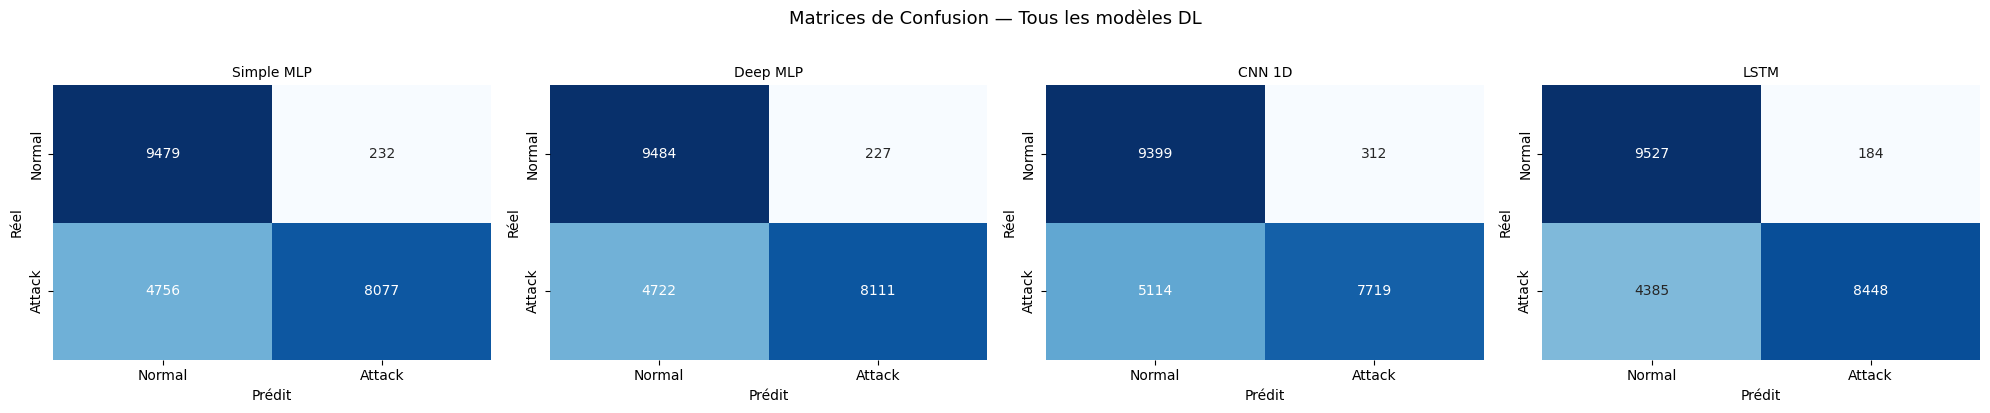

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'])
    ax.set_title(name.split(' - ')[-1], fontsize=10)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.suptitle("Matrices de Confusion — Tous les modèles DL", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## ⚠️ Étape 23 — Analyse des Faux Négatifs

Les **Faux Négatifs** sont particulièrement critiques en cybersécurité : une attaque non détectée peut causer des dommages majeurs.

In [31]:
print("=== Faux Négatifs par modèle ===")
for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    fn = cm[1, 0]
    fn_rate = fn / cm[1].sum() * 100
    print(f"{name.split(' - ')[-1]:<25} FN={fn:>5}  ({fn_rate:.2f}% des attaques non détectées)")

=== Faux Négatifs par modèle ===
Simple MLP                FN= 4756  (37.06% des attaques non détectées)
Deep MLP                  FN= 4722  (36.80% des attaques non détectées)
CNN 1D                    FN= 5114  (39.85% des attaques non détectées)
LSTM                      FN= 4385  (34.17% des attaques non détectées)


## 📈 Étape 24 — Courbes Precision-Recall

La courbe **Precision-Recall** est plus informative que la ROC dans les contextes déséquilibrés.  
L'aire sous la courbe (**PR-AUC**) résume la performance globale du détecteur.

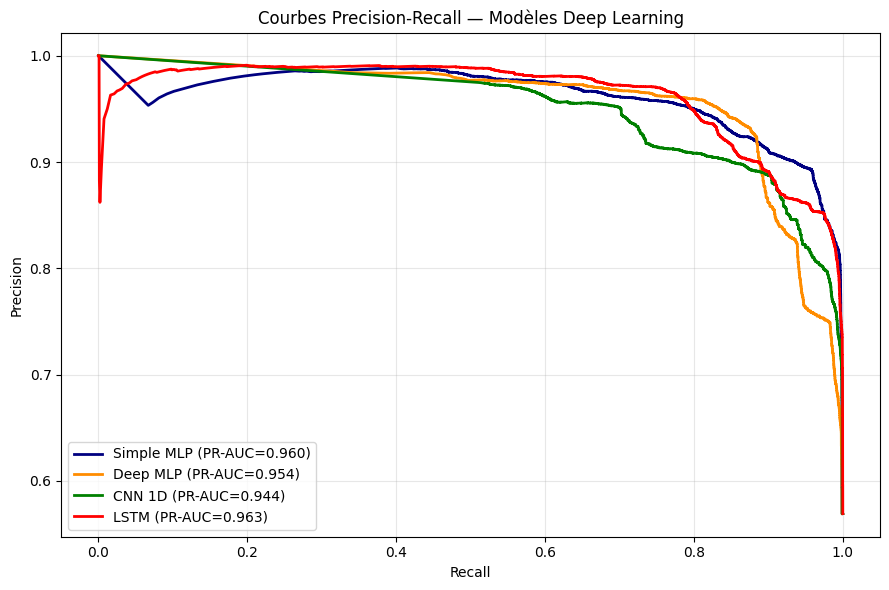

Clés disponibles dans results :
['model', 'y_pred', 'y_proba', 'Precision', 'Recall', 'F1', 'PR-AUC', 'ROC-AUC']


In [34]:
plt.figure(figsize=(9,6))
colors = ['navy','darkorange','green','red']

for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    plt.plot(rec, prec, color=color, lw=2,
             label=f"{name.split(' - ')[-1]} (PR-AUC={res['PR-AUC']:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbes Precision-Recall — Modèles Deep Learning")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Diagnostic — voir les vraies clés disponibles
print("Clés disponibles dans results :")
first_key = list(results.keys())[0]
print(list(results[first_key].keys()))

## 📋 Étape 25 — Rapport Final de Sécurité

### Synthèse du projet

Ce projet a démontré la faisabilité d'un **IDS interprétable basé sur le Deep Learning** combinant :

- ✅ **4 architectures DL** : MLP simple, Deep MLP, CNN 1D, LSTM
- ✅ **Explainabilité** : SHAP GradientExplainer (global + local) + LIME
- ✅ **Stabilité** : corrélation de Spearman sur perturbations
- ✅ **Robustesse adversariale** : attaque FGSM par gradient

### Implications de sécurité

| Risque | Impact | Mitigation |
|--------|--------|------------|
| Attaque FGSM | Évasion du détecteur | Adversarial Training |
| Instabilité des explications | Confiance réduite | Régularisation + ensembles |
| Exposition des SHAP values | Fuite d'information | Ne pas exposer en prod |
| Faux Négatifs | Attaques non détectées | Seuil de décision ajusté |

### Conclusion

> Le **Deep MLP** ou **CNN 1D** offrent le meilleur compromis performance/interprétabilité pour un IDS en production.  
> L'utilisation de **SHAP GradientExplainer** est essentielle pour maintenir la confiance des opérateurs SOC dans les décisions du modèle.

In [36]:
# Meilleur modèle sur PR-AUC (métrique IDS la plus pertinente)

best_name_final = max(results, key=lambda k: results[k]['PR-AUC'])

min_f1        = min(v['F1'] for v in results.values())
max_f1        = max(v['F1'] for v in results.values())
mean_stab_val = np.mean(stability_scores)

print("=" * 60)
print("         RAPPORT DE SÉCURITÉ — IDS DEEP LEARNING")
print("=" * 60)
print(f"\n📌 Meilleur modèle    : {best_name_final}")
print(f"📊 F1 min / max       : {min_f1:.4f} / {max_f1:.4f}")
print(f"🔍 Stabilité SHAP moy : {mean_stab_val:.4f}")
print(f"🔍 Stabilité LIME moy : {mean_stab_lime:.4f}")
print(f"⚠️  Taux d'évasion FGSM: {evasion_rate*100:.1f}%")

print("""
╔══════════════════════════════════════════════════════╗
║  1. MODÈLES : Baseline MLP → Deep MLP → CNN 1D → LSTM
║  2. EXPLAINABILITÉ : SHAP GradientExplainer + LIME
║  3. STABILITÉ : Spearman > 0.80 → explications fiables
║  4. ATTAQUE FGSM (réelle, par gradient) sur le modèle DL
║  5. RECOMMANDATIONS :
║     • Adversarial Training avec exemples FGSM
║     • Ne pas exposer les SHAP values en production
║     • Monitoring du drift des explications
║     • Ensemble de modèles DL pour réduire la surface
╚══════════════════════════════════════════════════════╝
""")

         RAPPORT DE SÉCURITÉ — IDS DEEP LEARNING

📌 Meilleur modèle    : Variation 3 - LSTM
📊 F1 min / max       : 0.7399 / 0.7871
🔍 Stabilité SHAP moy : 0.5836
🔍 Stabilité LIME moy : 0.0635
⚠️  Taux d'évasion FGSM: 6.2%

╔══════════════════════════════════════════════════════╗
║  1. MODÈLES : Baseline MLP → Deep MLP → CNN 1D → LSTM
║  2. EXPLAINABILITÉ : SHAP GradientExplainer + LIME
║  3. STABILITÉ : Spearman > 0.80 → explications fiables
║  4. ATTAQUE FGSM (réelle, par gradient) sur le modèle DL
║  5. RECOMMANDATIONS :
║     • Adversarial Training avec exemples FGSM
║     • Ne pas exposer les SHAP values en production
║     • Monitoring du drift des explications
║     • Ensemble de modèles DL pour réduire la surface
╚══════════════════════════════════════════════════════╝

